In [22]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.preprocessing import StandardScaler # 標準化
from sklearn import datasets
from sklearn.cluster import KMeans
import seaborn as sns


In [2]:
data = datasets.load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [3]:
print(df.columns)

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')


In [4]:
col_names_ja = {
    'alcohol': 'アルコール度数',
    'malic_acid': 'リンゴ酸',
    'ash': '灰分',
    'alcalinity_of_ash': '灰分のアルカリ度',
    'magnesium': 'マグネシウム',
    'total_phenols': '総フェノール量',
    'flavanoids': 'フラバノイド',
    'nonflavanoid_phenols': '非フラバノイド系フェノール',
    'proanthocyanins': 'プロアントシアニン',
    'color_intensity': '色の濃さ',
    'hue': '色相',
    'od280/od315_of_diluted_wines': '希釈ワインのOD280/OD315',
    'proline': 'プロリン',
}

df = df.rename(columns=col_names_ja)

In [7]:
print(df.head())

print(df.shape)

   アルコール度数  リンゴ酸    灰分  灰分のアルカリ度  マグネシウム  総フェノール量  フラバノイド  非フラバノイド系フェノール  \
0    14.23  1.71  2.43      15.6   127.0     2.80    3.06           0.28   
1    13.20  1.78  2.14      11.2   100.0     2.65    2.76           0.26   
2    13.16  2.36  2.67      18.6   101.0     2.80    3.24           0.30   
3    14.37  1.95  2.50      16.8   113.0     3.85    3.49           0.24   
4    13.24  2.59  2.87      21.0   118.0     2.80    2.69           0.39   

   プロアントシアニン  色の濃さ    色相  希釈ワインのOD280/OD315    プロリン  
0       2.29  5.64  1.04               3.92  1065.0  
1       1.28  4.38  1.05               3.40  1050.0  
2       2.81  5.68  1.03               3.17  1185.0  
3       2.18  7.80  0.86               3.45  1480.0  
4       1.82  4.32  1.04               2.93   735.0  
(178, 13)


In [13]:
# データの標準化
scaler = StandardScaler()
X = df.to_numpy()
X_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=df.columns)
df_scaled.head()

,アルコール度数,リンゴ酸,灰分,灰分のアルカリ度,マグネシウム,総フェノール量,フラバノイド,非フラバノイド系フェノール,プロアントシアニン,色の濃さ,色相,希釈ワインのOD280/OD315,プロリン
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [48]:
# 学習
model = KMeans(n_clusters=6, random_state=0)
model.fit(X_scaled)



,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [49]:
# クラスタリング結果の確認
model.labels_

array([2, 2, 2, 2, 3, 2, 2, 2, 5, 2, 2, 2, 2, 5, 5, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 4, 0,
       0, 0, 0, 0, 4, 4, 4, 3, 0, 0, 0, 4, 0, 4, 0, 0, 4, 1, 4, 0, 4, 4,
       4, 4, 4, 4, 4, 0, 0, 3, 4, 0, 0, 0, 0, 0, 4, 0, 0, 4, 0, 4, 0, 4,
       0, 4, 4, 4, 4, 0, 0, 4, 1, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [50]:
df_scaled['cluster'] = model.labels_
df_scaled.head()

,アルコール度数,リンゴ酸,灰分,灰分のアルカリ度,マグネシウム,総フェノール量,フラバノイド,非フラバノイド系フェノール,プロアントシアニン,色の濃さ,色相,希釈ワインのOD280/OD315,プロリン,cluster
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,2
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,2
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,2
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574,2
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874,3


<Axes: xlabel='cluster', ylabel='count'>

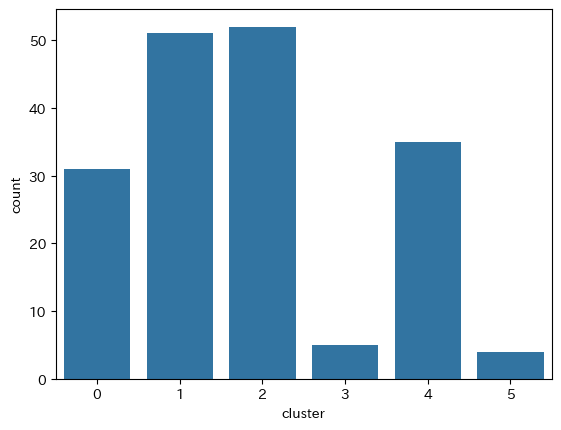

In [51]:
# クラスタリングしたデータの確認
# X軸がクラスターの種別で、ｙ軸がその数
sns.countplot(x='cluster', data=df_scaled)

In [52]:
df_copy = df.copy()
df_copy['cluster'] = model.labels_
df_copy.groupby('cluster').mean().sort_values(by='色の濃さ', ascending=False)

,アルコール度数,リンゴ酸,灰分,灰分のアルカリ度,マグネシウム,総フェノール量,フラバノイド,非フラバノイド系フェノール,プロアントシアニン,色の濃さ,色相,希釈ワインのOD280/OD315,プロリン
cluster,,,,,,,,,,,,,
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
5,14.252500,1.742500,2.245000,12.450000,95.500000,2.980000,3.395000,0.295000,2.665000,6.325000,1.162500,2.872500,1223.000000
2,13.741731,2.029231,2.455962,17.190385,106.769231,2.842692,2.968654,0.284423,1.851731,5.562885,1.051154,3.192308,1122.115385
3,12.662000,1.976000,2.824000,24.700000,132.400000,2.882000,3.122000,0.372000,2.170000,3.970000,1.114000,3.190000,790.400000
0,12.330000,1.519032,2.024194,17.854839,94.419355,2.386452,2.102581,0.311935,1.650000,3.241935,1.143871,2.790000,551.612903
4,12.204286,2.221143,2.410857,21.888571,91.400000,2.129143,2.020286,0.396000,1.594000,2.755714,0.994171,2.812000,488.028571


<Axes: xlabel='色の濃さ', ylabel='cluster'>

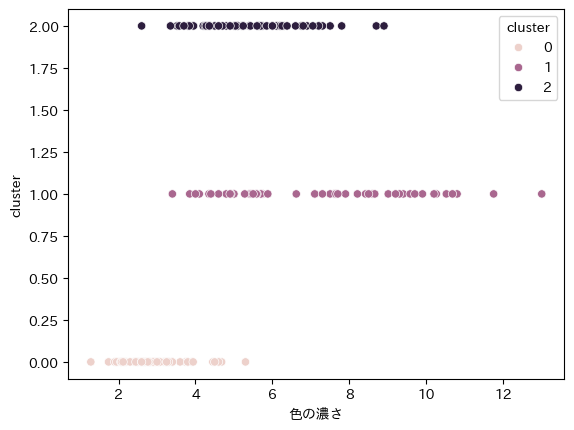

In [46]:
# 各クラスターと色の関係
sns.scatterplot(x='色の濃さ', y='cluster', data=df_copy, hue='cluster')

In [35]:
df.corr()

,アルコール度数,リンゴ酸,灰分,灰分のアルカリ度,マグネシウム,総フェノール量,フラバノイド,非フラバノイド系フェノール,プロアントシアニン,色の濃さ,色相,希釈ワインのOD280/OD315,プロリン
アルコール度数,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
リンゴ酸,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
灰分,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
灰分のアルカリ度,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
マグネシウム,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
総フェノール量,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
フラバノイド,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
非フラバノイド系フェノール,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
プロアントシアニン,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
色の濃さ,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


In [53]:
# 学習
model2 = KMeans(n_clusters=3, random_state=0)
model2.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [55]:
y_true = data.target
y_true

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [56]:
y_pred = model2.predict(X_scaled)
y_pred

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [57]:
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(y_true, y_pred)
print(f"ARI: {ari:.3f}")

ARI: 0.897


In [59]:
y_pred2 = model.predict(X_scaled)
ari2 = adjusted_rand_score(y_true, y_pred2)
print(f"ARI: {ari2:.3f}")

ARI: 0.692
